
# Reproduce the headline spectral-scaling figures

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/optimizer-scaling-laws/spectral-scaling-laws/blob/main/notebooks/reproduce_main_figures.ipynb)

This notebook regenerates the main 160M rank-scaling summaries from the lightweight processed CSVs committed in the repository. It does **not** train models, load checkpoints, or require a GPU.

The goal is to make the central claim easy to audit: the same GPT-2 160M architecture can show very different hard/soft spectral-rank scaling depending on the optimizer.



## Setup

When run inside a checked-out copy of the repository, the notebook uses local files. When opened directly in Colab, it clones the public repository and reads the committed processed CSVs.


In [1]:

from pathlib import Path
import os
import subprocess
import sys

REPO_URL = "https://github.com/optimizer-scaling-laws/spectral-scaling-laws.git"
REPO_DIR = Path("spectral-scaling-laws")

if not Path("results/processed").exists():
    # Colab path: clone the repository that contains the processed CSVs.
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL], check=True)
    os.chdir(REPO_DIR)

ROOT = Path.cwd()
PROCESSED = ROOT / "results" / "processed"
assert PROCESSED.exists(), f"Could not find processed artifacts at {PROCESSED}"
print(f"Using repository root: {ROOT}")


Using repository root: /mnt/data/work8m/spectral-scaling-laws


In [2]:

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

try:
    from scipy.stats import t as t_dist
except Exception:  # pragma: no cover - useful fallback outside Colab
    t_dist = None

plt.rcParams.update({
    "figure.dpi": 140,
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

OPTIMIZER_ORDER = ["adamw", "muon", "normuon", "dion_r1_2", "dion_r1_16"]
DISPLAY = {
    "adamw": "AdamW",
    "muon": "Muon",
    "normuon": "NorMuon",
    "dion_r1_2": "Dion (1/2)",
    "dion_r1_16": "Dion (1/16)",
}
METRIC_LABEL = {"hard_rank": "Hard spectral rank", "soft_rank": "Soft spectral rank"}
BUCKET_LABEL = {"head": "HEAD", "mid": "MID", "tail": "TAIL"}


def read_csv(name: str) -> pd.DataFrame:
    path = PROCESSED / name
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path)


def fit_power_law(points: pd.DataFrame) -> dict:
    """Fit y = A D^beta in log-log space."""
    x = points["ffn_hidden_dim"].to_numpy(dtype=float)
    y = points["value"].to_numpy(dtype=float)
    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x = np.log(x[mask])
    y = np.log(y[mask])
    n = len(x)
    if n < 3:
        return {"valid": False}

    xbar = x.mean()
    ybar = y.mean()
    sxx = ((x - xbar) ** 2).sum()
    beta = ((x - xbar) * (y - ybar)).sum() / sxx
    intercept = ybar - beta * xbar
    yhat = intercept + beta * x
    ss_res = ((y - yhat) ** 2).sum()
    ss_tot = ((y - ybar) ** 2).sum()
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else 1.0
    dof = n - 2
    std_err = math.sqrt((ss_res / dof) / sxx) if dof > 0 else float("nan")
    if t_dist is not None and dof > 0:
        ci_half = float(t_dist.ppf(0.975, dof)) * std_err
        ci_method = "analytic t interval"
    else:
        ci_half = 1.96 * std_err
        ci_method = "normal approximation"
    return {
        "valid": True,
        "beta": beta,
        "beta_lower": beta - ci_half,
        "beta_upper": beta + ci_half,
        "intercept": intercept,
        "r_squared": r2,
        "n_widths": n,
        "ci_method": ci_method,
    }


def recompute_beta_table(points: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    rows = []
    for keys, grp in points.groupby(group_cols, dropna=False):
        if not isinstance(keys, tuple):
            keys = (keys,)
        fit = fit_power_law(grp)
        if not fit.get("valid"):
            continue
        row = dict(zip(group_cols, keys))
        row.update(fit)
        rows.append(row)
    return pd.DataFrame(rows)



## Load processed rank-scaling artifacts


In [3]:

global_points = read_csv("global_rank_scaling_points.csv")
bucket_points = read_csv("frequency_bucket_rank_scaling_points.csv")
released_global_beta = read_csv("main_beta_table.csv")
released_bucket_beta = read_csv("frequency_bucket_beta_table.csv")

print("global_rank_scaling_points.csv", global_points.shape)
print("frequency_bucket_rank_scaling_points.csv", bucket_points.shape)
print("main_beta_table.csv", released_global_beta.shape)
print("frequency_bucket_beta_table.csv", released_bucket_beta.shape)


global_rank_scaling_points.csv (80, 22)
frequency_bucket_rank_scaling_points.csv (240, 22)
main_beta_table.csv (10, 16)
frequency_bucket_beta_table.csv (30, 18)



## Recompute beta exponents from the committed points

The next cell refits the power laws from the committed point estimates. This is the numerical source of the headline comparison: different optimizers realize different spectral-rank scaling exponents under the same model family.


In [4]:

live_global_beta = recompute_beta_table(
    global_points,
    ["optimizer_folder", "optimizer_display_name", "metric"],
)
live_bucket_beta = recompute_beta_table(
    bucket_points,
    ["optimizer_folder", "optimizer_display_name", "bucket", "metric"],
)

headline = (
    live_bucket_beta[
        (live_bucket_beta["bucket"] == "tail")
        & (live_bucket_beta["metric"].isin(["hard_rank", "soft_rank"]))
    ]
    .assign(
        beta=lambda d: d["beta"].round(3),
        r_squared=lambda d: d["r_squared"].round(3),
    )
    .pivot(index="optimizer_display_name", columns="metric", values=["beta", "r_squared"])
)

order = [DISPLAY[o] for o in OPTIMIZER_ORDER if DISPLAY[o] in headline.index]
headline = headline.loc[order]
display(Markdown("### TAIL-token scaling exponents recomputed live"))
display(headline)


### TAIL-token scaling exponents recomputed live

beta           r_squared          
metric                 hard_rank soft_rank hard_rank soft_rank
optimizer_display_name                                        
AdamW                      0.438     0.618     0.664     0.973
Muon                       1.021     1.026     0.808     0.942
NorMuon                    1.038     1.042     0.886     0.981
Dion (1/2)                 0.879     0.952     0.978     0.995
Dion (1/16)                0.404     0.718     0.989     0.998


## Figure 1: global hard/soft spectral-rank scaling

This reproduces the global FFN-rank scaling comparison from the committed point estimates.


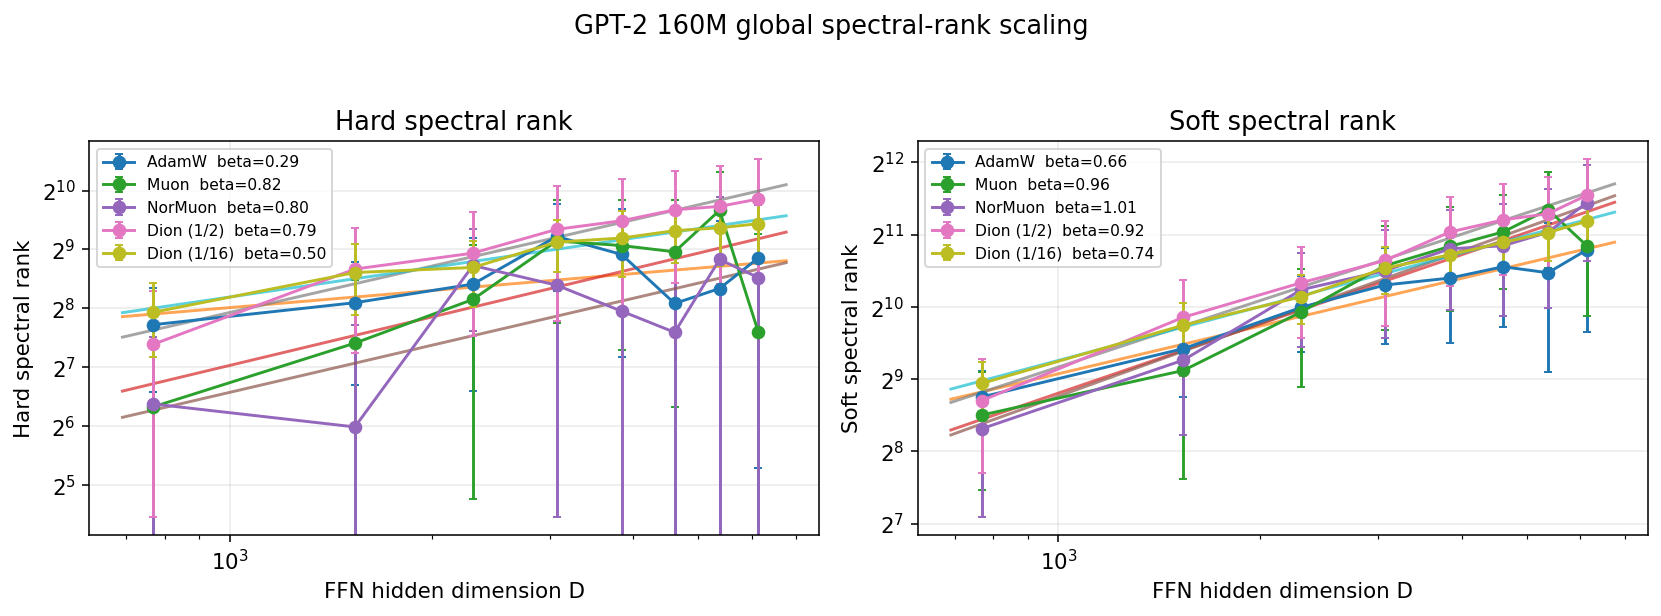

In [5]:

def plot_points_and_fits(points: pd.DataFrame, beta: pd.DataFrame, metric: str, ax, bucket: str | None = None):
    for opt in OPTIMIZER_ORDER:
        sub = points[(points["optimizer_folder"] == opt) & (points["metric"] == metric)].copy()
        bsub = beta[(beta["optimizer_folder"] == opt) & (beta["metric"] == metric)].copy()
        if bucket is not None:
            sub = sub[sub["bucket"] == bucket]
            bsub = bsub[bsub["bucket"] == bucket]
        if sub.empty or bsub.empty:
            continue
        sub = sub.sort_values("ffn_hidden_dim")
        label = f"{DISPLAY.get(opt, opt)}  beta={float(bsub.iloc[0]['beta']):.2f}"
        ax.errorbar(
            sub["ffn_hidden_dim"],
            sub["value"],
            yerr=[sub["value"] - sub["err_low"], sub["err_high"] - sub["value"]],
            marker="o",
            linewidth=1.5,
            capsize=2,
            label=label,
        )
        fit = bsub.iloc[0]
        x = np.logspace(
            np.log10(sub["ffn_hidden_dim"].min() * 0.9),
            np.log10(sub["ffn_hidden_dim"].max() * 1.1),
            80,
        )
        y = np.exp(float(fit["intercept"])) * x ** float(fit["beta"])
        ax.plot(x, y, alpha=0.7)

    ax.set_xscale("log")
    ax.set_yscale("log", base=2)
    ax.set_xlabel("FFN hidden dimension D")
    ax.set_ylabel(METRIC_LABEL[metric])
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, metric in zip(axes, ["hard_rank", "soft_rank"]):
    plot_points_and_fits(global_points, live_global_beta, metric, ax)
    ax.set_title(METRIC_LABEL[metric])
fig.suptitle("GPT-2 160M global spectral-rank scaling", y=1.04)
plt.tight_layout()
plt.show()



## Figure 2: HEAD/MID/TAIL frequency-bucket scaling

This is the central frequency-conditioned view: hard-rank scaling in TAIL tokens is where the optimizer-induced capacity difference is most visible.


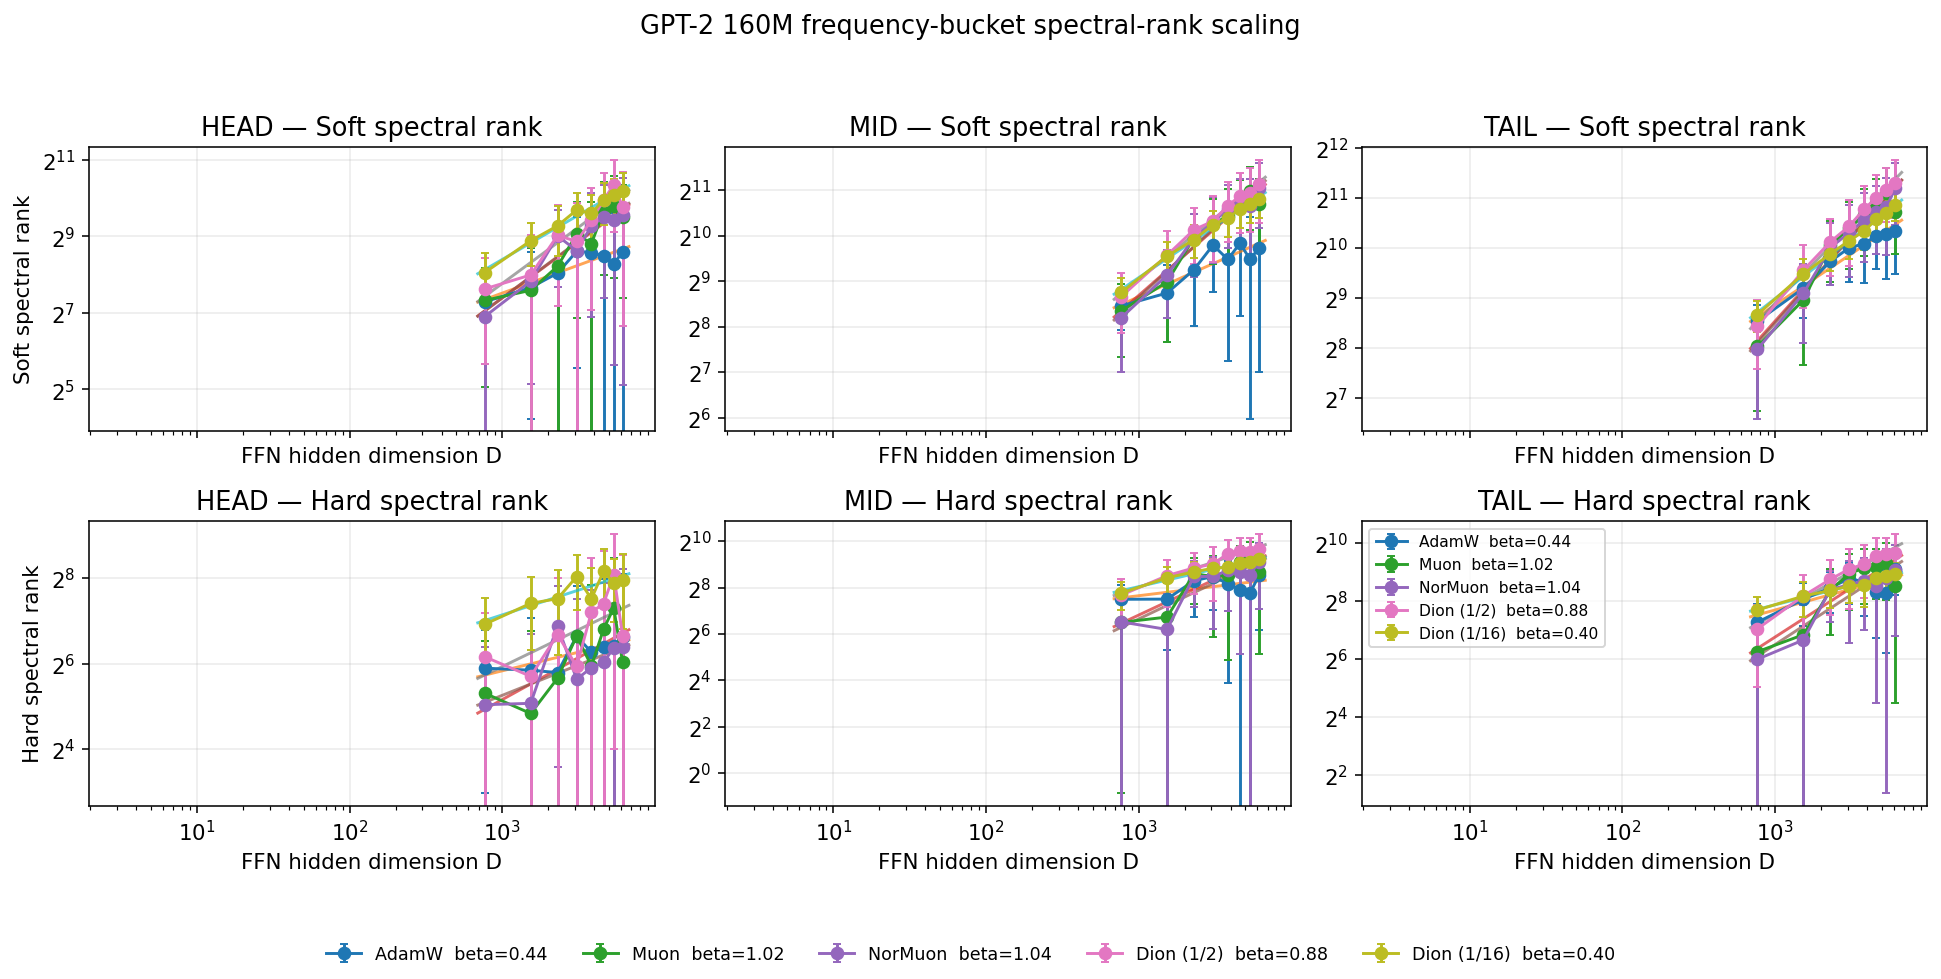

In [6]:

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
for row, metric in enumerate(["soft_rank", "hard_rank"]):
    for col, bucket in enumerate(["head", "mid", "tail"]):
        ax = axes[row, col]
        plot_points_and_fits(bucket_points, live_bucket_beta, metric, ax, bucket=bucket)
        ax.set_title(f"{BUCKET_LABEL[bucket]} — {METRIC_LABEL[metric]}")
        if col > 0:
            ax.set_ylabel("")
        if not (row == 1 and col == 2):
            ax.legend_.remove()

handles, labels = axes[1, 2].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=5, fontsize=9, frameon=False)
fig.suptitle("GPT-2 160M frequency-bucket spectral-rank scaling", y=0.98)
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()



## Quick numerical takeaway


In [7]:

def beta_value(df, optimizer, bucket, metric):
    row = df[(df["optimizer_folder"] == optimizer) & (df["bucket"] == bucket) & (df["metric"] == metric)].iloc[0]
    return float(row["beta"]), float(row["r_squared"])

adamw_tail_hard, adamw_tail_hard_r2 = beta_value(live_bucket_beta, "adamw", "tail", "hard_rank")
muon_tail_hard, muon_tail_hard_r2 = beta_value(live_bucket_beta, "muon", "tail", "hard_rank")
normuon_tail_hard, normuon_tail_hard_r2 = beta_value(live_bucket_beta, "normuon", "tail", "hard_rank")

summary_md = f"""
- AdamW TAIL hard-rank scaling: **beta = {adamw_tail_hard:.2f}** ($R^2={adamw_tail_hard_r2:.2f}$)
- Muon TAIL hard-rank scaling: **beta = {muon_tail_hard:.2f}** ($R^2={muon_tail_hard_r2:.2f}$)
- NorMuon TAIL hard-rank scaling: **beta = {normuon_tail_hard:.2f}** ($R^2={normuon_tail_hard_r2:.2f}$)

The same architecture therefore converts width into realized TAIL-token hard-rank capacity very differently depending on the optimizer.
"""
display(Markdown(summary_md))



- AdamW TAIL hard-rank scaling: **beta = 0.44** ($R^2=0.66$)
- Muon TAIL hard-rank scaling: **beta = 1.02** ($R^2=0.81$)
- NorMuon TAIL hard-rank scaling: **beta = 1.04** ($R^2=0.89$)

The same architecture therefore converts width into realized TAIL-token hard-rank capacity very differently depending on the optimizer.



## Optional: GPT-2 350M TAIL-token confirmation

The full paper repo also includes the 350M TAIL-token processed beta table. This table is smaller because the 350M experiment used four width points.


In [8]:

tail_350m_beta = read_csv("tail_350m_beta_table.csv")
tail_350m = (
    tail_350m_beta
    .assign(beta=lambda d: d["beta"].round(3), r_squared=lambda d: d["r_squared"].round(3))
    .pivot(index="optimizer_display_name", columns="metric", values=["beta", "r_squared"])
)
order_350 = [DISPLAY[o] for o in ["adamw", "muon", "normuon", "dion_r1_16"] if DISPLAY[o] in tail_350m.index]
display(tail_350m.loc[order_350])


beta           r_squared          
metric                 hard_rank soft_rank hard_rank soft_rank
optimizer_display_name                                        
AdamW                      0.388     0.573     0.823     0.949
Muon                       1.127     0.998     0.943     0.983
NorMuon                    0.881     0.919     0.983     0.989
Dion (1/16)                0.475     0.749     0.989     0.994


## Next steps

For the full set of committed paper figures, run this from the repository root:

```bash
make figures
```

The script path equivalent is:

```bash
bash scripts/reproduce/reproduce_main_results_from_processed.sh results/processed results/figures
```

For raw-log parsing and historical launch configs, see `docs/reproduction.md`, `docs/training.md`, and `results/figure_manifest.csv`.
